<a href="https://colab.research.google.com/github/chanu-24/car-vision-study/blob/main/Week2_Day2_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚌 1. 안전한 테스트 이미지 불러오기 (텐서 변환까지 한 번에!)

📦 2. [매우 중요] AI는 사진을 '박스(Batch)' 단위로 받습니다!
뇌에 들어갈 최종 텐서 모양: torch.Size([1, 3, 1080, 810]) ➔ (박스수, 색상, 세로, 가로)

🧠 3. 내 손으로 만드는 첫 AI 뇌세포 (CNN 돋보기) 생성!
AI 뇌세포 조립 완료! 이제 사진을 통과시킵니다 찌릿찌릿 ⚡

🖼️ 4. AI가 돋보기로 찾아낸 '자동차의 특징(Feature Map)' 시각화!


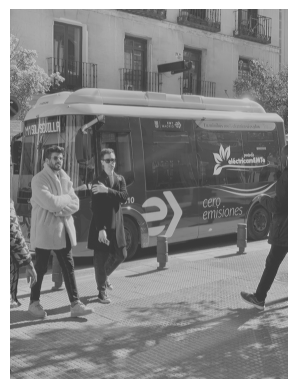

In [1]:
import torch
import torch.nn as nn
import cv2
import urllib.request
from torchvision import transforms
import matplotlib.pyplot as plt

print("🚌 1. 안전한 테스트 이미지 불러오기 (텐서 변환까지 한 번에!)")
url = 'https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg'
urllib.request.urlretrieve(url, 'bus.jpg')

# OpenCV로 읽고, RGB로 색상 순서 맞추기
img_cv2 = cv2.imread('bus.jpg')
img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

# 텐서로 변환 (C, H, W)
img_tensor = transforms.ToTensor()(img_cv2)

print("\n📦 2. [매우 중요] AI는 사진을 '박스(Batch)' 단위로 받습니다!")
# PyTorch 모델은 사진 한 장(3, H, W)을 주면 에러를 냅니다.
# 반드시 "박스 안에 사진 1장 들어있다!" 형태인 (1, 3, H, W)로 만들어줘야 합니다.
img_batch = img_tensor.unsqueeze(0) # 0번째 자리에 '1'이라는 박스 차원을 추가!
print(f"뇌에 들어갈 최종 텐서 모양: {img_batch.shape} ➔ (박스수, 색상, 세로, 가로)")


print("\n🧠 3. 내 손으로 만드는 첫 AI 뇌세포 (CNN 돋보기) 생성!")
# in_channels=3 : 들어오는 사진의 색상이 3개(RGB)
# out_channels=1 : 돋보기를 거쳐서 나올 특징 도화지는 1장!
# kernel_size=3 : 돋보기의 크기는 3x3 픽셀
conv_layer = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3)

print("AI 뇌세포 조립 완료! 이제 사진을 통과시킵니다 찌릿찌릿 ⚡")
# 사진을 뇌세포에 통과시킴!
feature_map = conv_layer(img_batch)


print("\n🖼️ 4. AI가 돋보기로 찾아낸 '자동차의 특징(Feature Map)' 시각화!")
# AI가 연산한 결과물(텐서)을 다시 우리가 볼 수 있게 화면에 출력합니다.
plt.imshow(feature_map[0, 0].detach().numpy(), cmap='gray')
plt.axis('off')
plt.show()


AI가 텐서라는 형태로 바꾸고 숫자(색상,세로,가로) 뒤집는 것까지 성공했습니다. AI의 뇌세포에 직접 통과시켜서 AI가 자동차의 특징을 어떻게 뽑아내는지 눈으로 확인해 노는것,

즉 AI가 자동차의 특징을 어떻게 뽑아내는지(추출하는지) 눈으로 확인해 보는것, (CNN) 합성곱 돋보기 만들기


아주 작은 돋보기,커널을 들고 사진의 왼쪽부터 오른쪽 아래까지 한칸씩 쓱 흝고 지나간다

돋보기의 역할 어떤 돋보기는 가로선만 찾고 어떤 돋보기는 세로선만 찾고 어떤 돋보기는 빨간색만 찾는다,

특징을 뽑아내어 새로운 도화지에 그리는 과정을 수학적으로 합성곱이라고 부른다, 이과 정을 거친 신경만을 CNN이라고 한다

방금 본 사진의 정체 (Feature Map): 이게 바로 AI가 돋보기(kernel_size=3)로 사진을 훑고 지나가면서 "어? 여긴 모서리네? 여긴 색깔이 확 변하네?" 하고 자기만의 언어로 스케치해 놓은 **'특징 맵(Feature Map)'**입니다! (우리가 만든 돋보기는 아직 학습을 안 한 '무작위 랜덤 돋보기'라서 좀 기괴하게 보일 수 있습니다 )

마의 에러 구간 타파 (unsqueeze(0)): 실무에서 초보자들이 제일 많이 겪는 에러가 바로 차원(Shape) 에러입니다. PyTorch 뇌는 사진 1장을 주면 안 먹고, 반드시 (Batch, Channel, Height, Width) 즉, (1, 3, H, W) 처럼 앞에 '박스 묶음 수'를 추가해 줘야만 연산이 돌아갑니다! 오늘 이걸 아신 것만으로도 실력 퀀텀 점프입니다.